# Classificação de flores Iris com MLP

## 1. Data load

In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import shap

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [6]:
iris = load_iris()
attributes = iris.data
species = iris.target

In [7]:
display(pd.DataFrame(attributes, columns=iris.feature_names).head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 1.1. Data Distribution

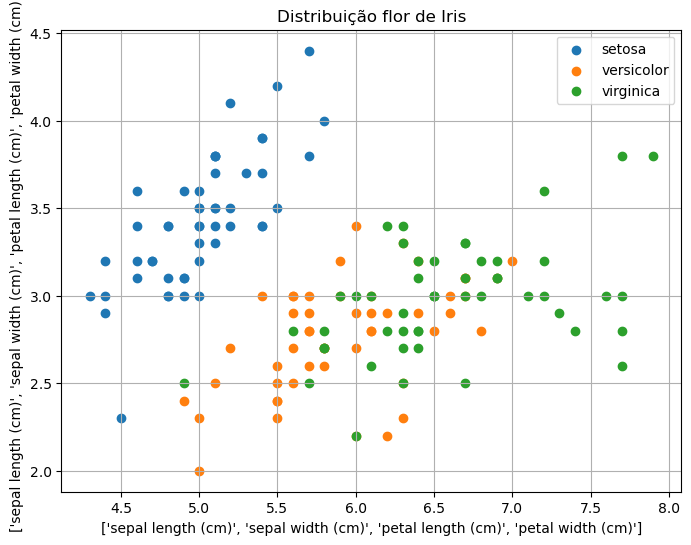

In [8]:
plt.figure(figsize=(8,6))
for i, target_name in enumerate(iris.target_names):
    plt.scatter(attributes[species == i, 0], attributes[species == i, 1], label=target_name)

plt.title("Distribuição flor de Iris")
plt.xlabel(iris.feature_names)
plt.ylabel(iris.feature_names)
plt.legend()
plt.grid(True)
plt.show()


### 1.2. One-Hot Encoding

In [9]:
encoder = OneHotEncoder(sparse_output=False)
species_encoded = encoder.fit_transform(species.reshape(-1, 1))

print("Exemplo de espécies codificas: ")
print(species_encoded[:5])

Exemplo de espécies codificas: 
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


### 1.3. Data Split

In [10]:
attr_train, attr_test, spec_train, spec_test = train_test_split(attributes, species_encoded, test_size=0.2, random_state=42)

### 1.4 normalization

In [11]:
normalizer = StandardScaler()
attr_train = normalizer.fit_transform(attr_train)
attr_test = normalizer.transform(attr_test)

## 2. Model and Train

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

In [16]:
opt = tf.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer="Adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(attr_train, spec_train, epochs=100, batch_size=5, validation_split=0.1, verbose=0)

I0000 00:00:1789406210.424477   20350 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14713__.16
I0000 00:00:1789406210.682751   20350 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14713__.16


## 3. Results

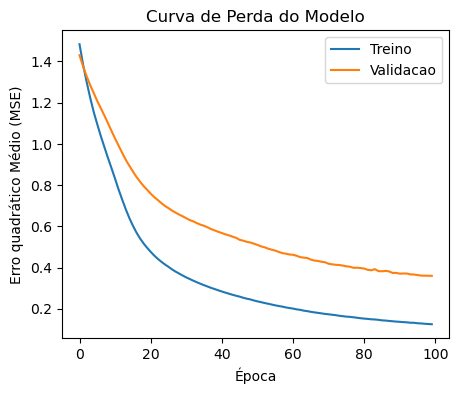

In [18]:
plt.figure(figsize=(5, 4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
plt.xlabel("Época")
plt.legend(["Treino", "Validacao"])

## 4. Avaliation

In [19]:
pred_prob = model.predict(attr_test)

class_pred = np.argmax(pred_prob, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step


In [20]:
class_real = np.argmax(spec_test, axis=1)

In [22]:
print(classification_report(class_real, class_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



<Figure size 500x400 with 0 Axes>

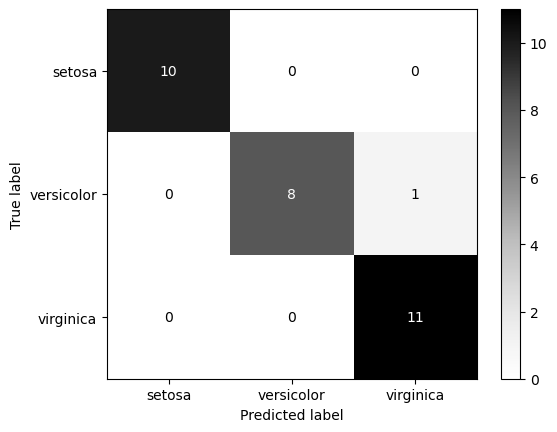

In [25]:
conf_matrix = confusion_matrix(class_real, class_pred)

plt.figure(figsize=(5,4))
display_matriz = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=iris.target_names)
display_matriz.plot(cmap="Greys", values_format='d')

In [36]:
explainer = shap.KernelExplainer(model.predict, attr_test[:50])
shap_values = explainer.shap_values(attr_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


  0%|          | 0/30 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━

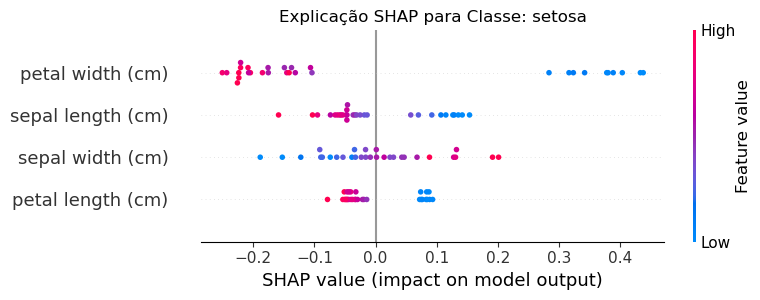

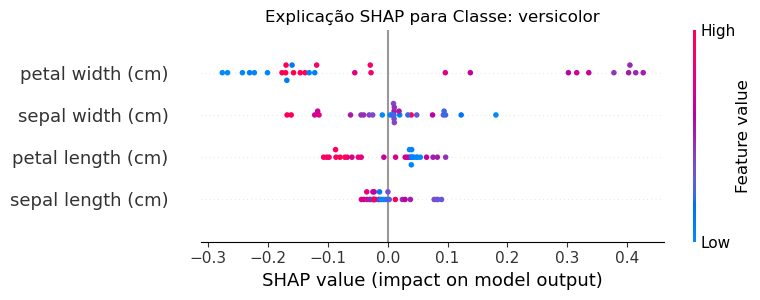

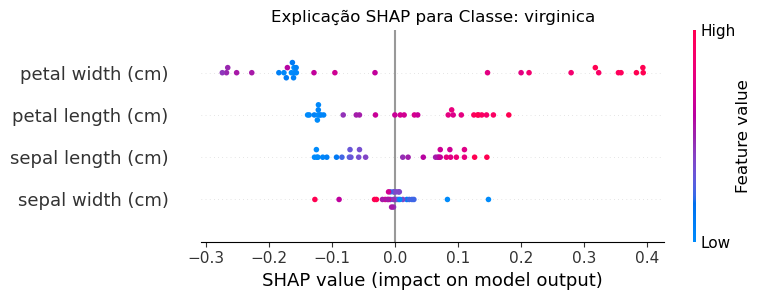

In [37]:
class_names = list(iris.target_names)

for i, class_name in enumerate(class_names):
    plt.figure(figsize=(6,3))
    plt.title(f"Explicação SHAP para Classe: {class_name}")
    shap_val_class = shap_values[:, :, i]

    shap.summary_plot(shap_val_class, attr_test, feature_names=iris.feature_names)
    plt.show()

In [41]:
shap.initjs()

amostra = 10
base_value_setosa = explainer.expected_value[0]
shap_val_setosa_amostra = shap_values[amostra, :, 0]

<Figure size 1000x300 with 0 Axes>

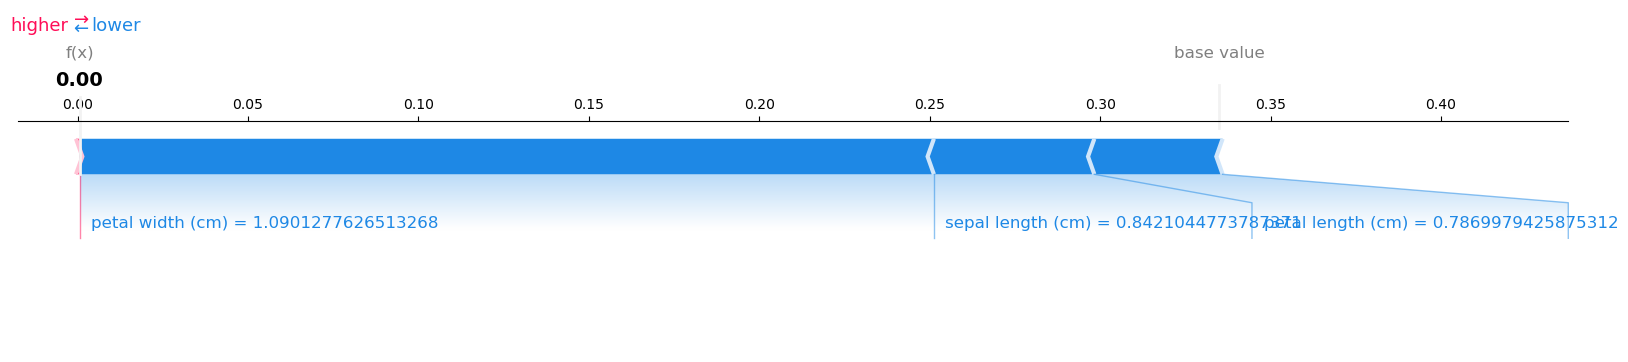

In [42]:
plt.figure(figsize=(10,3))
shap.force_plot(
    base_value_setosa,
    shap_val_setosa_amostra,
    attr_test[amostra],
    feature_names = iris.feature_names,
    matplotlib=True
)

plt.show()